In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv", index_col=0)
df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
id,,,,,,,,,
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


In [4]:
le = LabelEncoder()
df['Sex'] =le.fit_transform(df['Sex'])

df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
id,,,,,,,,,
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,0,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,2,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,2,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


In [6]:
y = df['Rings']
X = df.drop('Rings', axis=1)

In [7]:
Y = pd.get_dummies(y).values
X = X.values

In [8]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


In [9]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1])   # 클래스 수 맞춤
])

model.compile(
    optimizer="adam",
    loss="mse",   # one-hot이면 categorical_crossentropy
    metrics=["mse"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 47.7176 - mse: 47.7176 - val_loss: 8.8344 - val_mse: 8.8344
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.6781 - mse: 8.6781 - val_loss: 7.5073 - val_mse: 7.5073
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.9160 - mse: 7.9160 - val_loss: 7.1218 - val_mse: 7.1218
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.4640 - mse: 7.4640 - val_loss: 6.8824 - val_mse: 6.8824
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3784 - mse: 7.3784 - val_loss: 6.7364 - val_mse: 6.7364
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1437 - mse: 7.1437 - val_loss: 6.5234 - val_mse: 6.5234
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.2148 - mse: 7.2148 - val_loss: 6.3943 - val_mse: 6.3943
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1853 - mse: 7.1853 - val_loss: 6.2541 - val_mse: 6.2541
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


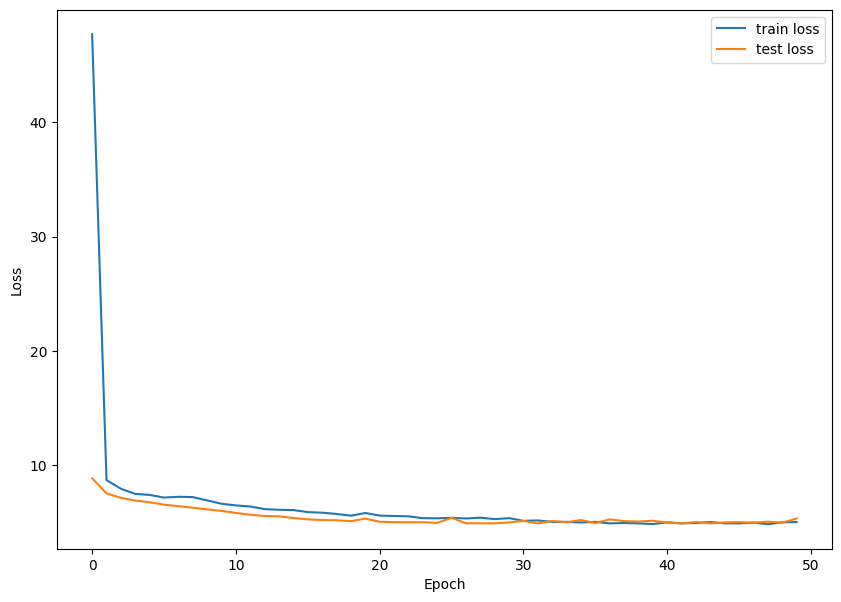

In [10]:
N_EPOCHS = 50
y_pred = model.predict(X_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3085 - mse: 5.3085


[5.308534622192383, 5.308534622192383]